In [2]:
import pandas as pd

df = pd.read_csv("lab4_data.csv")

if df["Churn"].dtype == "object":
    df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [3]:
#Overall churn probability
overall_churn = df["Churn"].mean()
print("Overall churn:",overall_churn)


Overall churn: 0.2653698707936959


In [4]:
#P(Churn | Contract = "Month-to-month")
p_month = df[df["Contract"] == "Month-to-month"]["Churn"].mean()
print("P(Churn | Contract = Month-to-month):",p_month)


P(Churn | Contract = Month-to-month): 0.4270967741935484


In [5]:
#P(Churn | tenure < 12 months)
p_tenure = df[df["tenure"] < 12]["Churn"].mean()
print("P(Churn | tenure < 12):", p_tenure)


P(Churn | tenure < 12): 0.4828419526341228


In [6]:
#P(Churn | InternetService = "Fiber optic")
p_fiber = df[df["InternetService"] == "Fiber optic"]["Churn"].mean()
print("P(Churn | Fiber optic):", p_fiber)


P(Churn | Fiber optic): 0.4189276485788114


In [7]:
#P(Churn | PaymentMethod = "Electronic check")
p_payment = df[df["PaymentMethod"] == "Electronic check"]["Churn"].mean()
print("P(Churn | Electronic check):", p_payment)


P(Churn | Electronic check): 0.4528541226215645


In [8]:
joint = df[
    (df["Contract"] == "Month-to-month") &
    (df["InternetService"] == "Fiber optic")
]

p_joint = joint["Churn"].mean()
print("P(Churn | Month-to-month & Fiber optic):", p_joint)


P(Churn | Month-to-month & Fiber optic): 0.5460526315789473


In [9]:
lift = p_joint / overall_churn
print("lift:", lift)


lift: 2.057703950888457


In [10]:
contract_churn = df.groupby("Contract")["Churn"].mean()
print(contract_churn)

lowest_contract = contract_churn.idxmin()
print("Lowest churn contract type:", lowest_contract)


Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64
Lowest churn contract type: Two year


In [11]:
senior_churn = df[df["SeniorCitizen"] == 1]["Churn"].mean()
non_senior_churn = df[df["SeniorCitizen"] == 0]["Churn"].mean()

print("Senior churn:", senior_churn)
print("Non-senior churn:", non_senior_churn)


Senior churn: 0.4168126094570928
Non-senior churn: 0.23606168446026096


In [12]:
paperless_yes = df[df["PaperlessBilling"] == "Yes"]["Churn"].mean()
paperless_no = df[df["PaperlessBilling"] == "No"]["Churn"].mean()

print("Paperless Yes churn:", paperless_yes)
print("Paperless No churn:", paperless_no)

print("Difference (Yes - No):", paperless_yes - paperless_no)

Paperless Yes churn: 0.33565092304003835
Paperless No churn: 0.1633008356545961
Difference (Yes - No): 0.17235008738544225


In [13]:
import numpy as np

categorical_cols = [
    col for col in df.select_dtypes(include="object").columns
    if col != "Churn"
]

categorical_cols

feature_diffs = {}

for col in categorical_cols:
    churn_rates = df.groupby(col)["Churn"].mean()
    max_diff = np.max(np.abs(churn_rates - overall_churn))
    feature_diffs[col] = max_diff

top5_features = sorted(feature_diffs, key=feature_diffs.get, reverse=True)[:5]
print("Top 5 most predictive features:", top5_features)


Top 5 most predictive features: ['customerID', 'TotalCharges', 'Contract', 'InternetService', 'OnlineSecurity']


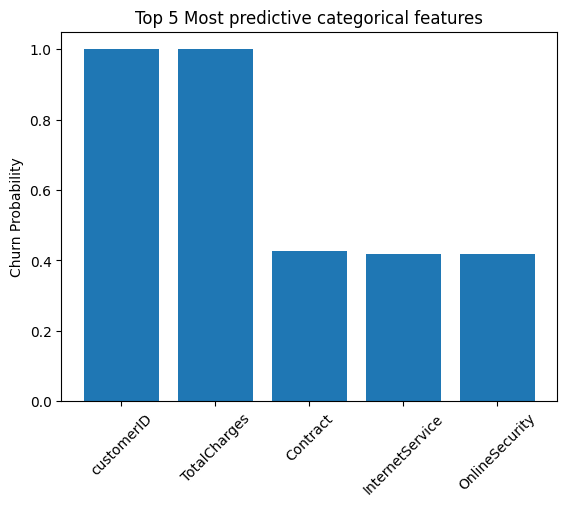

In [14]:
import matplotlib.pyplot as plt

feature_names = []
feature_probs = []

for col in top5_features:
    churn_rates = df.groupby(col)["Churn"].mean()
    feature_names.append(col)
    feature_probs.append(churn_rates.max())

plt.figure()
plt.bar(feature_names, feature_probs)
plt.xticks(rotation=45)
plt.ylabel("Churn Probability")
plt.title("Top 5 Most predictive categorical features")
plt.show()


In [15]:
#Convert TotalCharges to numeric and handle missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

#Decide how to treat numerical features (tenure, MonthlyCharges, TotalCharges):
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in df.columns if df[col].dtype == 'object' and col != 'customerID']

X = df[numerical_features + categorical_features].reset_index(drop=True)
y = df['Churn'].reset_index(drop=True)

np.random.seed(42)
indices = np.arange(len(df))
np.random.shuffle(indices)

#Split the data into training (80%) and test (20%) sets.
train_size = int(0.8 * len(df))
train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train = X.loc[train_idx].reset_index(drop=True)
y_train = y.loc[train_idx].reset_index(drop=True)

X_test = X.loc[test_idx].reset_index(drop=True)
y_test = y.loc[test_idx].reset_index(drop=True)

print("Training:", len(X_train))
print("Test:", len(X_test))


Training: 5634
Test: 1409


C:\Users\Assiya\AppData\Local\Temp\ipykernel_11604\2173593787.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [ ]:
#P(Churn) and P(No Churn) (training set)
prior_churn = y_train.mean()
prior_nochurn = 1 - prior_churn

print("P(Churn) =", prior_churn)
print("P(No Churn) =", prior_nochurn)


P(Churn) = 0.268370607028754
P(No Churn) = 0.7316293929712461


In [19]:
X_train_churn = X_train[y_train == 1]
X_train_no_churn = X_train[y_train == 0]

mean_churn = X_train_churn[numerical_features].mean()
std_churn = X_train_churn[numerical_features].std()

mean_no_churn = X_train_no_churn[numerical_features].mean()
std_no_churn = X_train_no_churn[numerical_features].std()

std_churn.replace(0, 1e-6, inplace=True)
std_no_churn.replace(0, 1e-6, inplace=True)

print("Mean (churn yes)")
print(mean_churn)

print("\nstd (churn yes)")
print(std_churn)

print("\nMean (churn no)")
print(mean_no_churn)

print("\nstd (churn no)")
print(std_no_churn)

Mean (churn yes)
tenure              17.865741
MonthlyCharges      74.421759
TotalCharges      1512.442659
dtype: float64

std (churn yes)
tenure              19.506617
MonthlyCharges      24.557145
TotalCharges      1875.076632
dtype: float64

Mean (churn no)
tenure              37.452935
MonthlyCharges      61.300825
TotalCharges      2545.406823
dtype: float64

std (churn no)
tenure              24.140168
MonthlyCharges      31.005793
TotalCharges      2329.595879
dtype: float64


In [ ]:
#P(feature = value | class) 
cat_probs = {}

for col in categorical_features:
    cat_probs[col] = {}
    for cls in [0, 1]:  
        subset = X_train[y_train==cls][col]
        value_counts = subset.value_counts()
        total = len(subset)
        probs = (value_counts + 1) / (total + len(value_counts))
        cat_probs[col][cls] = probs.to_dict()


In [ ]:
#
num_stats = {}

for col in numerical_features:
    num_stats[col] = {}
    for cls in [0,1]:
        subset = X_train[y_train==cls][col]
        num_stats[col][cls] = {
            'mean': subset.mean(),
            'std': subset.std()
        }
print(subset.mean())
print(subset.std())

1512.4426587301587
1875.0766316823815


In [ ]:
from math import exp, sqrt, pi

def gaussian_prob(x, mean, std):
    return (1 / (sqrt(2*pi)*std)) * exp(-((x - mean)**2) / (2*std**2))

def predict_nb(X):
    preds = []
    probs = []
    
    for i in range(len(X)):
        p_churn = prior_churn
        p_nochurn = prior_nochurn
        
#categorical
        for col in categorical_features:
            val = X.iloc[i][col]
            p_churn *= cat_probs[col][1].get(val, 1e-6)
            p_nochurn *= cat_probs[col][0].get(val, 1e-6)
        
#num
        for col in numerical_features:
            mean1, std1 = num_stats[col][1]['mean'], num_stats[col][1]['std']
            mean0, std0 = num_stats[col][0]['mean'], num_stats[col][0]['std']
            x_val = X.iloc[i][col]
            
            p_churn *= gaussian_prob(x_val, mean1, std1)
            p_nochurn *= gaussian_prob(x_val, mean0, std0)
        
#normalize
        total = p_churn + p_nochurn
        prob_churn = p_churn / total
        probs.append(prob_churn)
        preds.append(1 if prob_churn > 0.5 else 0)
    
    return np.array(preds), np.array(probs)


y_pred, y_prob = predict_nb(X_test)

print("First 10 predicted classes (0=No churn, 1=Churn):")
print(y_pred[:10])

print("\nFirst 10 predicted probabilities of churn:")
print(y_prob[:10])

print("\nNumber of predicted churners:", np.sum(y_pred))
print("Number of predicted non-churners:", len(y_pred) - np.sum(y_pred))


First 10 predicted classes (0=No churn, 1=Churn):
[1 0 0 0 0 0 0 1 1 0]

First 10 predicted probabilities of churn:
[9.76011909e-01 1.32054822e-02 1.12052249e-01 3.09085524e-04
 2.38968027e-02 4.55272382e-01 2.82780680e-01 9.87863829e-01
 9.50575674e-01 7.48227059e-06]

Number of predicted churners: 579
Number of predicted non-churners: 830


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

y_pred, y_prob = predict_nb(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", round(acc,4))
print("Precision:", round(prec,4))
print("Recall:", round(rec,4))
print("F1-score:", round(f1,4))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


Accuracy: 0.7275
Precision: 0.4767
Recall: 0.7731
F1-score: 0.5897
Confusion Matrix:
 [[749 303]
 [ 81 276]]


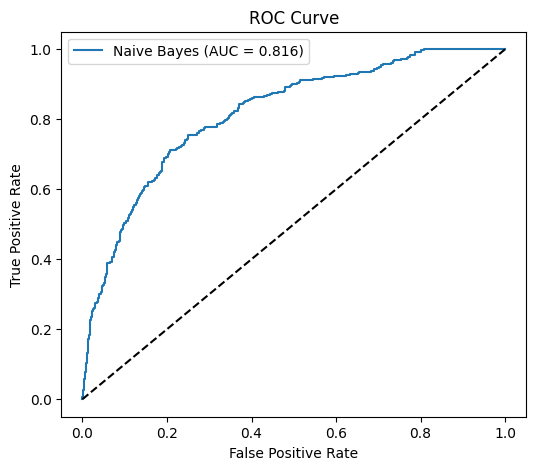

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label='Naive Bayes (AUC = %0.3f)' % roc_auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


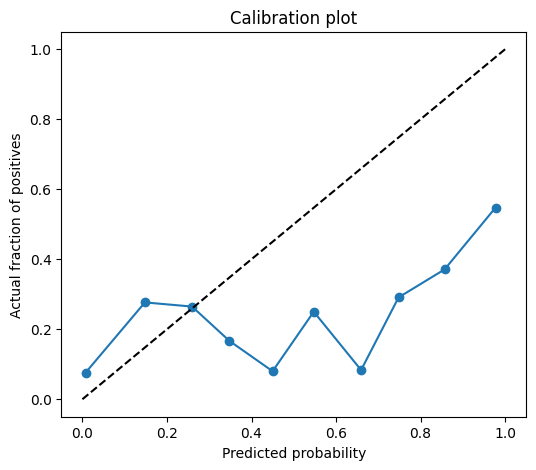

In [ ]:
bins = np.linspace(0,1,11)
binids = np.digitize(y_prob, bins) - 1
bin_true = np.zeros(10)
bin_pred = np.zeros(10)

for i in range(10):
    idx = binids == i
    if np.sum(idx) > 0:
        bin_true[i] = np.mean(y_test.values[idx])
        bin_pred[i] = np.mean(y_prob[idx])

plt.figure(figsize=(6,5))
plt.plot(bin_pred, bin_true, marker='o')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("Predicted probability")
plt.ylabel("Actual fraction of positives")
plt.title("Calibration plot")
plt.show()


In [ ]:
from sklearn.naive_bayes import GaussianNB, CategoricalNB

gnb = GaussianNB()
gnb.fit(X_train[numerical_features], y_train)
y_pred_gnb = gnb.predict(X_test[numerical_features])
y_prob_gnb = gnb.predict_proba(X_test[numerical_features])[:,1]

print("GaussianNB accuracy:", round(accuracy_score(y_test, y_pred_gnb),4))


GaussianNB accuracy: 0.7594


In [ ]:
p_churn = 0.8       
CLV = 2000         
success_rate = 0.4 
campaign_cost = 300


max_spend = p_churn * CLV * success_rate
print("Maximum spend for this customer: $", round(max_spend, 2))


Maximum spend for this customer: $ 640.0


In [ ]:
target_customers = X_test[y_prob > 0.5].index
expected_profits = y_prob[target_customers] * 2000 * 0.4 - 300
total_expected_profit = expected_profits.sum()

print(total_expected_profit)

251281.770113185


In [ ]:

high_value_threshold = 70    
high_risk_threshold = 0.6

X_test['HighValue'] = X_test['MonthlyCharges'] > high_value_threshold
X_test['HighRisk'] = y_prob > high_risk_threshold

def quadrant(row):
    if row['HighValue'] and row['HighRisk']:
        return 'HV/HR'
    elif row['HighValue'] and not row['HighRisk']:
        return 'HV/LR'
    elif not row['HighValue'] and row['HighRisk']:
        return 'LV/HR'
    else:
        return 'LV/LR'

X_test['Quadrant'] = X_test.apply(quadrant, axis=1)

results = []

for quad, group in X_test.groupby('Quadrant'):
    n_customers = len(group)
    expected_loss = (y_prob[group.index] * CLV).sum()
    expected_gain = ((y_prob[group.index] * CLV * success_rate) - campaign_cost).sum()
    results.append([quad, n_customers, round(expected_loss,2), round(expected_gain,2)])

risk_matrix = pd.DataFrame(results, columns=['Quadrant', 'Number of Customers', 
                                             'Expected Loss ($)', 'Expected Net Gain ($)'])

print(risk_matrix)


  Quadrant  Number of Customers  Expected Loss ($)  Expected Net Gain ($)
0    HV/HR                  365          689583.77              166333.51
1    HV/LR                  357           55546.00              -84881.60
2    LV/HR                  198          355358.79               82743.52
3    LV/LR                  489           42970.92             -129511.63


In [ ]:
X_test['EV'] = y_prob * 2000 * 0.4 - 300
top_customers = X_test.sort_values('EV', ascending=False)
budget = 50000
top_customers['cumulative_cost'] = 300 * np.arange(1, len(top_customers)+1)
selected = top_customers[top_customers['cumulative_cost'] <= budget]

num_targeted = len(selected)
total_expected_profit = selected['EV'].sum()
high_risk_coverage = (selected['HighRisk'].sum() / X_test['HighRisk'].sum()) * 100

print("Number of customers targeted:", num_targeted)
print("Total expected profit from the campaign: $", total_expected_profit)
print("Percentage of high-risk segment covered:", high_risk_coverage)

Number of customers targeted: 166
Total expected profit from the campaign: $ 82588.06836750265
Percentage of high-risk segment covered: 29.484902309058615


In [ ]:
scenarios = {
    "Success rate drops to 20%": {"success_rate": 0.2, "campaign_cost": 300, "CLV": 2000},
    "Retention cost rises to $500": {"success_rate": 0.4, "campaign_cost": 500, "CLV": 2000},
    "Average CLV is $1,500": {"success_rate": 0.4, "campaign_cost": 300, "CLV": 1500}
}

budget = 50000

for scenario_name, params in scenarios.items():
    sr = params['success_rate']
    cost = params['campaign_cost']
    clv = params['CLV']
    
    X_test['EV'] = y_prob * clv * sr - cost
    
    top_customers = X_test.sort_values('EV', ascending=False)
    
    top_customers['cumulative_cost'] = cost * np.arange(1, len(top_customers)+1)
    selected = top_customers[top_customers['cumulative_cost'] <= budget]
    
    num_targeted = len(selected)
    total_expected_profit = selected['EV'].sum()
    high_risk_coverage = (selected['HighRisk'].sum() / X_test['HighRisk'].sum()) * 100
    
    print(f"\nScenario: {scenario_name}")
    print("Number of customers targeted:", num_targeted)
    print("Total expected profit: $", round(total_expected_profit,2))
    print("Percentage of high-risk segment covered:", round(high_risk_coverage,2), "%")
    
    if total_expected_profit > 0:
        print("Decision: Run the campaign")
    else:
        print("Decision: Do NOT run the campaign")



Scenario: Success rate drops to 20%
Number of customers targeted: 166
Total expected profit: $ 16394.03
Percentage of high-risk segment covered: 29.48 %
Decision: Run the campaign

Scenario: Retention cost rises to $500
Number of customers targeted: 100
Total expected profit: $ 29859.3
Percentage of high-risk segment covered: 17.76 %
Decision: Run the campaign

Scenario: Average CLV is $1,500
Number of customers targeted: 166
Total expected profit: $ 49491.05
Percentage of high-risk segment covered: 29.48 %
Decision: Run the campaign
